In [ ]:
# TODO: formulate optimization problem! optimize n_eval too?

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from scipy.signal import wiener, butter, freqs, convolve, freqz
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq, fft2, ifft2
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
import cv2
from scipy.signal import convolve2d as conv2
from skimage import color, data, restoration
from scipy.signal import wiener, convolve2d
from smooth_POD_ROM.pre_processing import gaussian, gaussian_f, convolve_f, convolve_f2D, smoothen
from ezyrb import POD, RBF, Database, Linear, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from datetime import datetime


In [235]:
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/Burger/"
X_train = np.load(pth+"X_train.npy")
X_test = np.load(pth+"X_test.npy")
X_val = np.load(pth+"X_val.npy")

mu_train = np.load(pth+"mu_train.npy")
mu_test = np.load(pth+"mu_test.npy")
mu_val = np.load(pth+"mu_val.npy")[:, None]

is_inside = mu_val[:, 0]<=0.9
mu_val = mu_val[is_inside]
X_val = X_val[:, is_inside]
print(X_train.shape, X_test.shape, X_val.shape)
print(mu_train.shape, mu_test.shape, mu_val.shape)

# smooth_ROM_sharpened = np.load(pth+"X_test_sROMs.npy")
# smooth_ROM = np.load(pth+"X_test_sROM.npy")

shape = (257, 257)
x = y = np.linspace(0, 1, 257, endpoint=True)
dx = x[1]-x[0]
sigma = 3.1*dx
rank = len(mu_train)

(66049, 10) (66049, 20) (66049, 901)
(10,) (20, 1) (901, 1)


In [241]:
X_test = X_val[:, ::20]
mu_test = mu_val[::20, :]
print(mu_test.shape, X_test.shape)

(46, 1) (66049, 46)


In [242]:
def train_ROM(mu, X):
    db = Database(mu[:, None], X.T)
    pod = POD(method="svd", rank=rank)  # = rom.reduction
    reg = RegularGrid()  # = rom.approximation
    rom = ROM(db, pod, reg)
    rom.fit()
    # pod.fit(db.snapshots.T)  # performs SVD
    # reduced_output = pod.transform(db.snapshots.T).T  # transform reduces the given snapshots. = VT.T
    # reg.fit(db.parameters, reduced_output)  # construct interpolators from points and values!
    return rom

def L2_eror(X, X_truth):
    return np.mean((X-X_truth)**2, axis=0)**.5

# standard ROM approach

0.024141835577684435


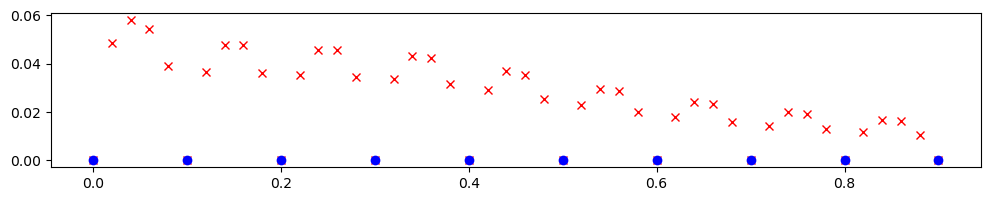

In [243]:
standard_rom = train_ROM(mu_train, X_train)
X_test_ROM = standard_rom.predict(mu_test).T
e_ROM = L2_eror(X_test_ROM, X_test)
mean_eROM = np.mean(e_ROM)

plt.figure(figsize=(12, 2))
plt.plot(mu_test, e_ROM, "rx")
plt.plot(mu_train, np.zeros_like(mu_train), "bo")
print(mean_eROM)

# regularized ROM with Richardson Lucy post processing

In [244]:
def neares_neighbour(x, x_all):
    return np.min(np.abs(x-x_all))


def get_sigma(sigma, mu, mu_train, c):
    d = neares_neighbour(mu, mu_train)
    dmu = mu_train[1]-mu_train[0]  # assumes uniform spacing!
    return sigma*(1+ c * d/dmu)


def richardson_lucy(x, im_blur, sgm, num_iter=1000, truth=None):
    assert len(im_blur.shape)==2, "image needs to be 2D"
    dx = x[1]-x[0]
    psf_f = gaussian_f(x, sgm)
    psf_f2D = np.outer(psf_f, psf_f)

    im_deconv = im_blur.copy()
    eps = 1e-12  # regularization to avoid 0 division
    for _ in range(num_iter):
        #blurred = convolve2d(im_deconv.copy(), psf, boundary='symm', mode='same') + eps
        #blurred = convolve_f2D(im_deconv, psf_f2D) + eps
        blurred = gaussian_filter(im_deconv, sigma=sgm/dx, truncate=4) + eps
        relative_blur = im_blur / blurred
        #im_deconv *= convolve2d(relative_blur, psf_mirror, boundary='symm', mode='same')
        #im_deconv *= convolve_f2D(relative_blur, psf_f2D)
        im_deconv *= gaussian_filter(relative_blur, sigma=sgm/dx, truncate=4) + eps
        if isinstance(truth, np.ndarray):
            print(_, np.mean((truth-im_deconv.ravel())**2)**.5)
#     fig, (ax1, ax2) = plt.subplots(1, 2)
#     ax1.imshow(im_blur.reshape(shape))
#     ax2.imshow(im_deconv.reshape(shape))
#     plt.show()
    return im_deconv


def post_process(x, data, sigma, c, mu_test, mu_train):
    deconvolved = np.empty_like(data)
    for j in range(len(mu_test)):
        sgm_est = get_sigma(sigma, mu_test[j], mu_train, c=c)
        deconvolved[:, j] = richardson_lucy(x, data[:, j].reshape(shape), sgm_est, num_iter=15).ravel()
    return deconvolved

## optimization of hyper parameters using test set

In [ ]:
from scipy.optimize import minimize
x0 = np.array([3.1*dx, 1.0])

def zielfunktion(params):
    sigma, c = params[0], params[1]
    X_train_s = smoothen(X_train, sigma/dx, shape)
    smooth_rom = train_ROM(mu_train, X_train_s)
    X_test_sROM = smooth_rom.predict(mu_test).T
    e_sROM = L2_eror(X_test_sROM, X_test)

    X_test_sROMs = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train)
    e_sROMs = L2_eror(X_test_sROMs, X_test)
    mean_sROMs = np.mean(e_sROMs)
    print(sigma/dx, c, mean_sROMs)
    return mean_sROMs

res = minimize(zielfunktion, x0, method='nelder-mead',
               options={'xatol': 1e-6, 'disp': True})

print(res)

3.1 1.0 0.02359671828385596
3.2550000000000003 1.0 0.02340759740174128
3.1 1.05 0.023604631960873333
3.2550000000000003 0.95 0.023387632544338115
3.3325000000000005 0.8999999999999999 0.02329123284235329
3.4875000000000003 0.8999999999999999 0.023171678391428866
3.6812500000000012 0.8499999999999996 0.023062795306579474
3.7587500000000014 0.7499999999999996 0.022951960915885163
4.010625000000002 0.6249999999999991 0.02283362263835365
4.359375000000003 0.5749999999999988 0.0228664588713724


In [221]:
# brute force:
sigmas = np.arange(2.5, 4.5, 0.1)*dx
cs = np.arange(.0, 1.8, 0.1)
print(len(sigmas), len(cs), len(sigmas)*len(cs), "evaluations")
# sigmas = [4.3 * dx]
# cs = [0.3]
error_matrix_sROM = np.empty((len(sigmas), len(mu_test)))
error_matrix_sROMs = np.empty((len(sigmas), len(cs), len(mu_test)))
e_min = mean_eROM
for i, sigma in enumerate(sigmas):
    X_train_s = smoothen(X_train, sigma/dx, shape)
    smooth_rom = train_ROM(mu_train, X_train_s)
    X_test_sROM = smooth_rom.predict(mu_test).T
    e_sROM = L2_eror(X_test_sROM, X_test)
    error_matrix_sROM[i] = e_sROM
    for j, c in enumerate(cs):
        print(i, j)
        X_test_sROMs = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train)
        e_sROMs = L2_eror(X_test_sROMs, X_test)
        error_matrix_sROMs[i, j] = e_sROMs
        mean_sROMs = np.mean(e_sROMs)
#         if np.mean(e_sROMs) < mean_eROM:
#             print(sigma, c, np.mean(e_ROM), np.mean(e_sROM), np.mean(e_sROMs))
        
#         plt.imshow(X_test_ROM[:, 0].reshape(shape))
#         plt.show()
#         plt.imshow(X_test_sROM[:, 0].reshape(shape))
#         plt.show()
#         plt.imshow(X_test_sROMs[:, 0].reshape(shape))
#         plt.show()
np.mean(e_sROMs)

print(c, np.mean(e_sROMs))

10 13 130 evaluations
0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
2 10
2 11
2 12
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
3 10
3 11
3 12
4 0
4 1
4 2
4 3
4 4
4 5
4 6
4 7
4 8
4 9
4 10
4 11
4 12
5 0
5 1
5 2
5 3
5 4
5 5
5 6
5 7
5 8
5 9
5 10
5 11
5 12
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
6 9
6 10
6 11
6 12
7 0
7 1
7 2
7 3
7 4
7 5
7 6
7 7
7 8
7 9
7 10
7 11
7 12
8 0
8 1
8 2
8 3
8 4
8 5
8 6
8 7
8 8
8 9
8 10
8 11
8 12
9 0
9 1
9 2
9 3
9 4
9 5
9 6
9 7
9 8
9 9
9 10
9 11
9 12
1.6999999999999997 0.026865291402521335


0.025937242937674573
0.025375109418949278 0.027357315408998318
0.023464060244877252 0.026865291402521335
0.9046474330853048


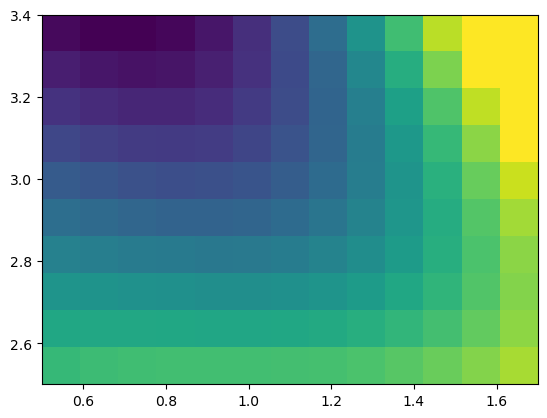

0.025125439146473354
0.023464060244877252
9 2 3.400000000000001 0.7


In [222]:
# find best parameter
mean_eROM = np.mean(e_ROM)
mean_esROM = np.mean(error_matrix_sROM, axis=-1)
mean_esROMs = np.mean(error_matrix_sROMs, axis=-1)

print(mean_eROM)
print(np.min(mean_esROM), np.max(mean_esROM))
print(np.min(mean_esROMs), np.max(mean_esROMs))
print(np.min(mean_esROMs)/mean_eROM)
fig, ax = plt.subplots()
ax.imshow(mean_esROMs, interpolation="nearest", origin="lower", vmax=mean_eROM*1.0, extent=(cs[0], cs[-1], sigmas[0]/dx, sigmas[-1]/dx))
ax.set_aspect("auto")
plt.show()
print(np.min(mean_esROMs[0, :]))
print(np.min(mean_esROMs[-1, :]))
i, j = np.unravel_index(np.argmin(mean_esROMs, axis=None), mean_esROMs.shape)
print(i, j, sigmas[i]/dx, cs[j])
sigma, c = sigmas[i], cs[j]

In [223]:
# run validation:
standard_rom = train_ROM(mu_train, X_train)
X_val_ROM = standard_rom.predict(mu_val).T
e_ROM = L2_eror(X_val_ROM, X_val)
print(np.mean(e_ROM))

X_train_s = smoothen(X_train, sigma/dx, shape)

smooth_rom = train_ROM(mu_train, X_train_s)
X_val_sROM = smooth_rom.predict(mu_val).T
e_sROM = L2_eror(X_val_sROM, X_val)
print(np.mean(e_sROM))

X_val_sROMs = post_process(x, X_val_sROM, sigma, c, mu_val, mu_train)
e_sROMs = L2_eror(X_val_sROMs, X_val)


print(sigma, c, np.mean(e_sROMs))

0.025937242937674573
0.027494960962479657
0.013281250000000003 0.7 0.023400945035938526


0.025937242937674573
0.027494960962479657
0.013281250000000003 0.7 0.023400945035938526


Text(0.5, 1.0, '0.9022140515153982')

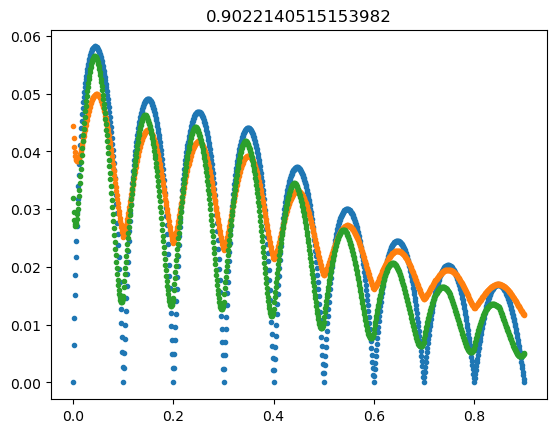

In [224]:
print(np.mean(e_ROM))
print(np.mean(e_sROM))
print(sigma, c, np.mean(e_sROMs))
# 0.025937242937674573
# 0.027494960962479657
# 0.013281250000000003 0.7 0.023400945035938526
plt.plot(mu_val, e_ROM, "C0.")
plt.plot(mu_val, e_sROM, "C1.")
plt.plot(mu_val, e_sROMs, "C2.")
plt.title(np.mean(e_sROMs)/np.mean(e_ROM))

sigma, c = 3.4, 0.7  # rel improvement: 0.902214

True
False


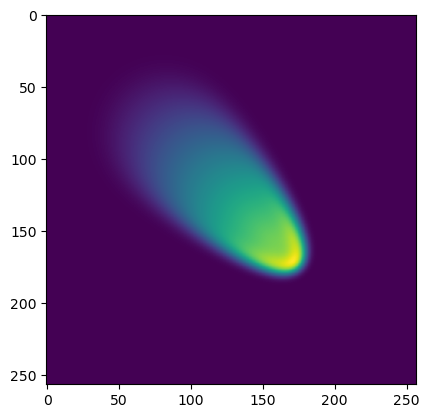

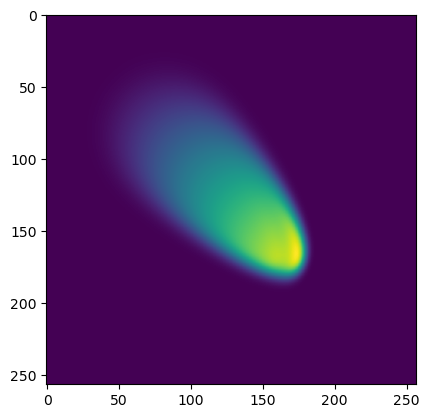

In [123]:
print(np.allclose(smooth_ROM, X_test_sROM))
print(np.allclose(deconvolved, X_test_sROMs))
plt.imshow(deconvolved[:, 0].reshape(shape))
plt.show()
plt.imshow(X_test_sROMs[:, 0].reshape(shape))
plt.show()

In [ ]:
X_train_s = np.empty_like(X_train)
for j in range(len(mu_train)):
    ss2D = X_train[:, j].reshape(shape)
    X_train_s[:, j] = gaussian_filter(ss2D, sigma=sigma, truncate=12).ravel()
X_test_s = np.empty_like(X_train)
for j in range(len(mu_train)):
    ss2D = X_test[:, j].reshape(shape)
    X_test_s[:, j] = gaussian_filter(ss2D, sigma=sigma, truncate=12).ravel()

In [ ]:
plt.plot(mu_train, np.ones_like(mu_train), "bo")
plt.plot(mu_test, np.ones_like(mu_test), "rx")

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
ax1.imshow(X_test[:, 0].reshape(257, 257), origin="lower", interpolation="nearest")
ax2.imshow(X_test_s[:, 0].reshape(257, 257), origin="lower", interpolation="nearest")
ax3.imshow(X_test_sROM[:, 0].reshape(257, 257), origin="lower", interpolation="nearest")

In [84]:
def richardson_lucy(im_blur, sgm, num_iter=1000, truth=None):
    psf_f = gaussian_f(x, sgm)
    psf_f2D = np.outer(psf_f, psf_f)

    im_deconv = im_blur.copy()
    eps = 1e-12  # regularization to avoid 0 division
    for _ in range(num_iter):
        #blurred = convolve2d(im_deconv.copy(), psf, boundary='symm', mode='same') + eps
        #blurred = convolve_f2D(im_deconv, psf_f2D) + eps
        blurred = gaussian_filter(im_deconv, sigma=sgm/dx, truncate=4) + eps
        relative_blur = im_blur / blurred
        #im_deconv *= convolve2d(relative_blur, psf_mirror, boundary='symm', mode='same')
        #im_deconv *= convolve_f2D(relative_blur, psf_f2D)
        im_deconv *= gaussian_filter(relative_blur, sigma=sgm/dx, truncate=4) + eps
        if isinstance(truth, np.ndarray):
            print(_, np.mean((truth-im_deconv.ravel())**2)**.5)
    return im_deconv


def sharpen3(data, sigma, c, mu_sample, mu_train):
    sgm_est = get_sigma(sigma, mu_sample, mu_train, c=c)
    return richardson_lucy(data, sgm_est, num_iter=30)

0.0172
[[ 3.08270767e-15  2.72496559e-16 -4.45013031e-15 ...  6.28949282e-57
   1.33632109e-57  3.31218996e-58]
 [ 9.13271799e-16  1.30733442e-15  2.23961684e-15 ...  8.82127144e-57
   1.87234216e-57  4.63477164e-58]
 [ 1.57920800e-15  2.23961684e-15  3.79489097e-15 ...  1.47964657e-56
   3.13636348e-57  7.75044883e-58]
 ...
 [ 6.28949282e-57  8.82127144e-57  1.47964657e-56 ... -5.27177044e-66
  -2.50307040e-66  9.90912998e-67]
 [ 1.33632109e-57  1.87234216e-57  3.13636348e-57 ... -2.50307041e-66
   2.38633783e-66  3.20112807e-66]
 [ 3.31218996e-58  4.63477164e-58  7.75044883e-58 ...  9.90912996e-67
   3.20112807e-66  2.11212599e-66]]
0.00390625 RL sigma= 0.0172 5 0.015689266775654048
0 0.01271731393116684
1 0.01130100590708422
2 0.010373295655139315
3 0.009688022707607116
4 0.0091483948595354


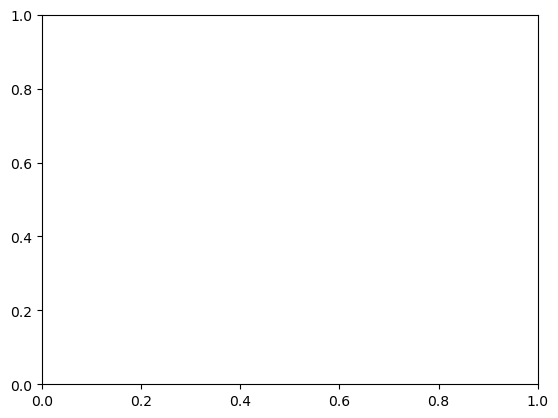

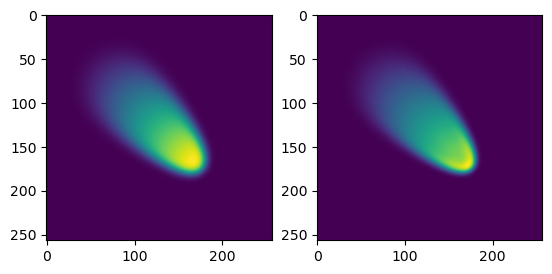

0 [0.892] 0.008000000000000007 0.008772508604931771 0.0091483948595354
0.018560546875
[[ 5.23471396e-15  5.76539827e-31 -3.01735621e-30 ...  1.21550328e-72
   2.73895141e-73  6.31026046e-74]
 [ 1.95634001e-31  2.70172059e-31  4.36609037e-31 ...  1.97622553e-72
   3.89991095e-73  9.63155813e-74]
 [ 3.38972630e-31  4.73546063e-31  8.00279585e-31 ...  2.79218147e-72
   6.67194899e-73  1.62066939e-73]
 ...
 [ 1.25440665e-72  1.59407741e-72  2.79218147e-72 ... -1.18333804e-81
  -4.88753516e-82  1.87396223e-82]
 [ 2.63446895e-73  3.94224335e-73  6.69416261e-73 ... -5.13706546e-82
   4.76423488e-82  6.06707038e-82]
 [ 6.96837445e-74  8.96285611e-74  1.49339853e-73 ...  1.91828312e-82
   6.41860193e-82  4.34341538e-82]]
0.00390625 RL sigma= 0.018560546875 5 0.0499928492246649
0 0.04518160094177139
1 0.04381925120729481
2 0.043591463665373045
3 0.04382612363182706
4 0.04425699443702323


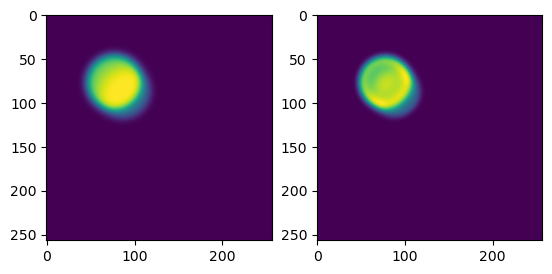

1 [0.035] 0.035 0.0466474451826512 0.04425699443702323
0.01851015625
[[ 1.03239436e-14  5.28956004e-15 -1.15835442e-30 ...  1.10532591e-72
   2.45854411e-73  6.35578912e-74]
 [ 1.47668482e-31  2.15197669e-31  4.62192251e-31 ...  1.67557996e-72
   3.46338020e-73  8.66198869e-74]
 [ 2.74238307e-31  4.06340560e-31  7.08043804e-31 ...  2.72076871e-72
   5.89774097e-73  1.36897643e-73]
 ...
 [ 1.02849617e-72  1.56061211e-72  2.72076871e-72 ... -9.62887341e-82
  -4.23694942e-82  1.54804763e-82]
 [ 2.49757364e-73  3.02672957e-73  5.45073686e-73 ... -4.51304221e-82
   3.91107043e-82  5.82156156e-82]
 [ 5.66574436e-74  7.97713060e-74  1.34548705e-73 ...  1.88903842e-82
   5.88114484e-82  3.74798182e-82]]
0.00390625 RL sigma= 0.01851015625 5 0.04233292074617311
0 0.03940514218689428
1 0.03875332605819853
2 0.03861559195798733
3 0.038672270679895565
4 0.038819521083031557


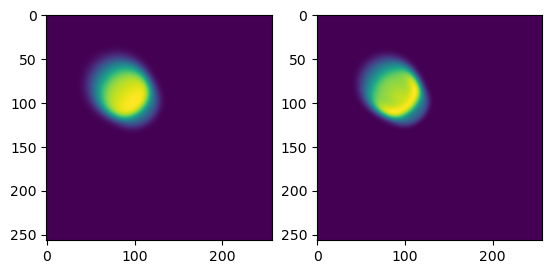

2 [0.134] 0.034 0.03937345434226547 0.038819521083031557
0.01689765625
[[ 2.56870839e-16 -3.85808625e-15 -4.68415884e-15 ...  2.57535033e-72
   5.81629413e-73  1.54349835e-73]
 [ 1.34876057e-24  1.36097339e-24  8.52495484e-26 ...  3.74815180e-72
   7.86182408e-73  2.04874838e-73]
 [ 1.78724905e-24  8.52494829e-26 -7.02048126e-24 ...  5.87330529e-72
   1.37211968e-72  3.36829662e-73]
 ...
 [ 2.71504452e-72  3.50992576e-72  5.87330529e-72 ... -2.36567841e-81
  -1.15584137e-81  3.61366083e-82]
 [ 5.10431721e-73  8.21105955e-73  1.29577670e-72 ... -1.15459655e-81
   9.93136338e-82  1.36102320e-81]
 [ 1.34339553e-73  1.93008556e-73  2.95635324e-73 ...  3.39535001e-82
   1.26805541e-81  8.76725329e-82]]
0.00390625 RL sigma= 0.01689765625 5 0.022845703045775802
0 0.019831743050609613
1 0.018504177640831326
2 0.01767609073620841
3 0.017083389097793333
4 0.016626267986523502


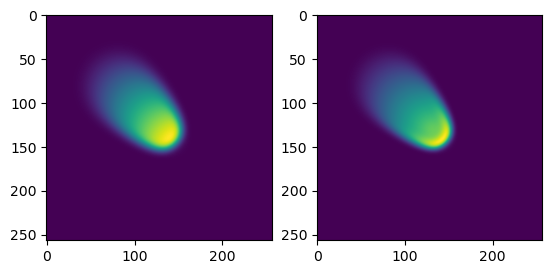

3 [0.502] 0.0020000000000000018 0.014148895529669928 0.016626267986523502
0.018963671875
[[ 8.52510560e-15 -4.33083842e-31 -2.23510381e-30 ...  1.28529225e-72
   2.76996289e-73  6.51106469e-74]
 [ 1.96863203e-31  2.64708378e-31  4.85240369e-31 ...  2.03163796e-72
   4.12754788e-73  1.02095452e-73]
 [ 3.43735128e-31  4.81562718e-31  8.03646211e-31 ...  2.93550412e-72
   6.57017581e-73  1.55219619e-73]
 ...
 [ 1.19038359e-72  1.64826494e-72  2.93550412e-72 ... -1.18980108e-81
  -5.10346526e-82  2.13913555e-82]
 [ 2.68192423e-73  3.80184186e-73  6.42758795e-73 ... -5.19161748e-82
   4.59490723e-82  6.66540622e-82]
 [ 7.25649168e-74  9.37422360e-74  1.54833033e-73 ...  2.04080304e-82
   6.52723521e-82  4.48988009e-82]]
0.00390625 RL sigma= 0.018963671875 5 0.04951221274029555
0 0.04451400456224003
1 0.0429364654797918
2 0.04248938086961835
3 0.042523061628192055
4 0.04277782478641856


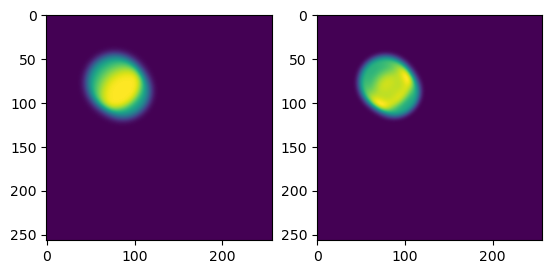

4 [0.057] 0.043000000000000003 0.04754295867067201 0.04277782478641856
0.018862890624999996
[[ 1.31444311e-15  2.82826173e-15  3.57790620e-16 ...  1.35958523e-72
   3.02057156e-73  8.04269453e-74]
 [ 3.98436796e-23  4.38438439e-23  1.65966037e-23 ...  1.98763920e-72
   4.27867716e-73  9.97562944e-74]
 [ 5.74935639e-23  1.65966037e-23 -1.71948176e-22 ...  3.72638976e-72
   6.13271622e-73  1.69748923e-73]
 ...
 [ 1.38760104e-72  1.57692615e-72  3.72638976e-72 ... -2.57052128e-81
  -2.05866572e-81 -1.36937740e-81]
 [ 3.09061108e-73  3.55280739e-73  6.38080442e-73 ... -2.15732106e-81
  -1.16376616e-81 -1.03283680e-81]
 [ 6.89127783e-74  9.35540892e-74  1.62685974e-73 ... -1.39270164e-81
  -9.37149835e-82 -1.30863883e-81]]
0.00390625 RL sigma= 0.018862890624999996 5 0.027733385230416914
0 0.024762925247221058
1 0.023357918360436363
2 0.022498146467146252
3 0.021936322577464033
4 0.021559294708897895


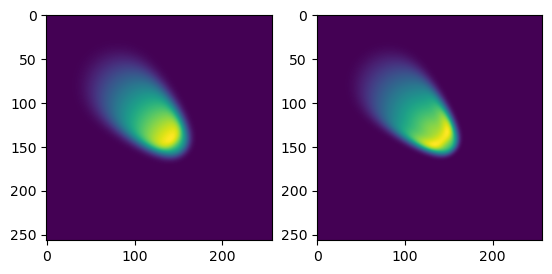

5 [0.559] 0.040999999999999925 0.024268682708893024 0.021559294708897895
0.01810703125
[[ 4.87408233e-15  1.15125718e-14 -1.32128778e-31 ...  7.40195301e-74
  -4.03559632e-76  6.11745985e-76]
 [-4.27221577e-32 -2.98525992e-32  3.72969328e-33 ... -2.71999427e-73
   1.04674180e-74 -1.53963203e-74]
 [-3.05438740e-32 -2.05120756e-32  6.77087550e-33 ... -1.22660159e-73
  -4.43139426e-74 -2.03164001e-74]
 ...
 [-8.75879830e-74 -1.67270011e-73 -1.22660159e-73 ...  5.58674818e-83
   3.59015069e-83 -1.01704104e-83]
 [-1.17879116e-74 -9.16933940e-76 -2.60385554e-74 ...  7.44640989e-83
  -1.20258536e-82 -1.09888216e-82]
 [-5.06700529e-75 -6.07820802e-75  6.95711624e-76 ...  3.73029746e-88
  -2.90461341e-83 -6.95525265e-84]]
0.00390625 RL sigma= 0.01810703125 5 0.039225221521964546
0 0.03447047096066067
1 0.032295711412822774
2 0.03100164446562096
3 0.03017884579035265
4 0.029646162158573044


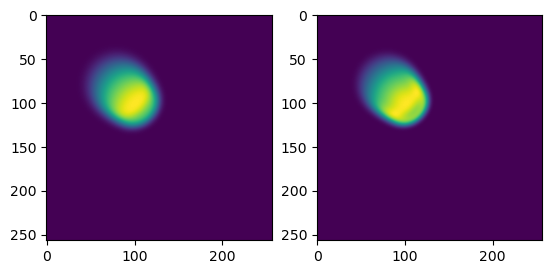

6 [0.174] 0.025999999999999995 0.03434675141438001 0.029646162158573044
0.017703906250000002
[[ 1.74118279e-15  5.52626179e-15  2.39226146e-15 ...  1.10789974e-72
   2.03365094e-73  5.79469715e-74]
 [ 5.53767171e-23  6.09860548e-23  2.32590800e-23 ...  1.63157369e-72
   2.18944470e-73  6.89264158e-74]
 [ 7.99715506e-23  2.32590800e-23 -2.38497947e-22 ...  2.10586266e-72
   3.35526495e-73  1.25794353e-73]
 ...
 [ 1.05485801e-72  1.27786140e-72  2.10586266e-72 ... -2.78232295e-81
  -2.48526112e-81 -2.04788534e-81]
 [ 2.25478406e-73  2.58744655e-73  3.79740531e-73 ... -2.46181709e-81
  -1.83717737e-81 -1.91400317e-81]
 [ 4.57884263e-74  7.99814983e-74  9.26306793e-74 ... -2.02658582e-81
  -1.97916061e-81 -2.05923508e-81]]
0.00390625 RL sigma= 0.017703906250000002 5 0.02380693093010575
0 0.020184701231501897
1 0.01826074710294341
2 0.01696442812030055
3 0.016017465131263217
4 0.015293298196409198


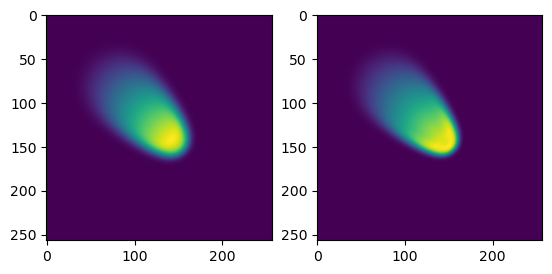

7 [0.582] 0.018000000000000016 0.0170338503085918 0.015293298196409198
0.017603125
[[ 5.16625431e-16 -2.21582534e-15 -3.44578529e-15 ...  2.45321020e-72
   5.18407853e-73  1.44370347e-73]
 [ 1.08036530e-23  1.17953627e-23  4.14066988e-24 ...  3.67556158e-72
   8.11227446e-73  1.85076894e-73]
 [ 1.54695019e-23  4.14066989e-24 -4.75290376e-23 ...  6.12436052e-72
   1.31970731e-72  3.21415918e-73]
 ...
 [ 2.41591193e-72  3.59045681e-72  6.12436052e-72 ... -2.52263811e-81
  -1.51435912e-81 -8.46697749e-84]
 [ 5.09083285e-73  8.01902879e-73  1.32592369e-72 ... -1.41121994e-81
   5.52740315e-82  8.56118844e-82]
 [ 1.33195769e-73  1.84628229e-73  2.80963689e-73 ... -2.74859577e-83
   8.66850963e-82  4.60956627e-82]]
0.00390625 RL sigma= 0.017603125 5 0.025124307901776777
0 0.02271125548839578
1 0.021791453171106024
2 0.021284193981287298
3 0.020968166499386952
4 0.02075806493937856


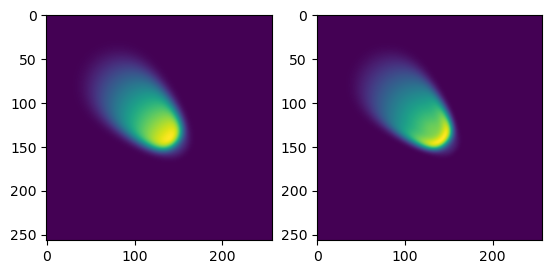

8 [0.516] 0.016000000000000014 0.018072162121700385 0.02075806493937856
0.017603125
[[ 1.27763811e-14  2.48920472e-15 -1.06655503e-30 ...  1.30920666e-72
   2.81376944e-73  7.13245532e-74]
 [ 1.77582674e-31  2.50782936e-31  5.08134655e-31 ...  1.94892154e-72
   4.44901358e-73  9.89928281e-74]
 [ 3.22790804e-31  5.19961077e-31  7.65664217e-31 ...  3.14191639e-72
   7.10251760e-73  1.80141473e-73]
 ...
 [ 1.13359874e-72  1.77225999e-72  3.14191639e-72 ... -1.18567526e-81
  -4.94784391e-82  2.00439366e-82]
 [ 2.90051958e-73  3.84487025e-73  6.56336171e-73 ... -5.16475917e-82
   4.48291746e-82  7.15126379e-82]
 [ 6.69989081e-74  9.69784390e-74  1.66006227e-73 ...  2.11402272e-82
   6.82548313e-82  4.67739086e-82]]
0.00390625 RL sigma= 0.017603125 5 0.036031265094564
0 0.03299562194952677
1 0.03212568128798709
2 0.03173627133010174
3 0.03153170390792401
4 0.03141906970368328


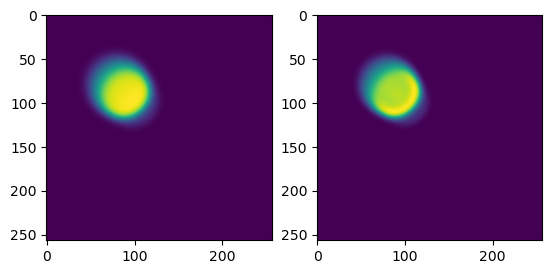

9 [0.116] 0.016 0.027746045162624047 0.03141906970368328
0.01730078125
[[ 1.49563256e-15 -6.42141021e-31 -3.19804597e-30 ...  7.38734661e-73
   1.91018310e-73  4.02126800e-74]
 [ 1.30958346e-31  1.97621096e-31  2.86878897e-31 ...  1.29404484e-72
   2.67475440e-73  6.09249475e-74]
 [ 2.30446188e-31  3.50140641e-31  4.91703328e-31 ...  1.73431738e-72
   4.44803374e-73  9.16128734e-74]
 ...
 [ 7.52181508e-73  9.90938797e-73  1.73431738e-72 ... -7.59183963e-82
  -3.38162559e-82  1.33210048e-82]
 [ 1.78074936e-73  2.64515476e-73  4.64210229e-73 ... -3.20168826e-82
   2.90051674e-82  3.80592237e-82]
 [ 5.25953473e-74  5.79990995e-74  8.61357295e-74 ...  1.14151483e-82
   4.43154963e-82  2.92372471e-82]]
0.00390625 RL sigma= 0.01730078125 5 0.04511596964293858
0 0.039582274155908516
1 0.03701383103030151
2 0.03551746232635229
3 0.034544694411527896
4 0.03386724445976056


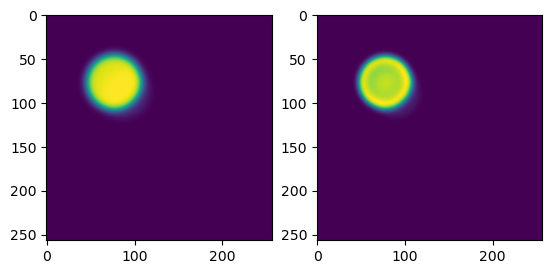

10 [0.01] 0.01 0.030047734174106288 0.03386724445976056
0.0190140625
[[ 2.61234559e-15  2.18033424e-15 -4.19855502e-15 ...  3.82838800e-57
   8.13413015e-58  2.01611596e-58]
 [ 5.61161108e-16  8.04642262e-16  1.38138447e-15 ...  5.36947114e-57
   1.13968679e-57  2.82116583e-58]
 [ 9.72270278e-16  1.38138447e-15  2.34613029e-15 ...  9.00654712e-57
   1.90909127e-57  4.71766537e-58]
 ...
 [ 3.82838800e-57  5.36947114e-57  9.00654712e-57 ... -3.20889577e-66
  -1.52360353e-66  6.03168416e-67]
 [ 8.13413015e-58  1.13968679e-57  1.90909127e-57 ... -1.52360353e-66
   1.45254640e-66  1.94849910e-66]
 [ 2.01611596e-58  2.82116583e-58  4.71766537e-58 ...  6.03168415e-67
   1.94849910e-66  1.28561957e-66]]
0.00390625 RL sigma= 0.0190140625 5 0.018669260187540684
0 0.01596674655809428
1 0.01474373540130754
2 0.013956978063719648
3 0.013388496474194145
4 0.0129542041561274


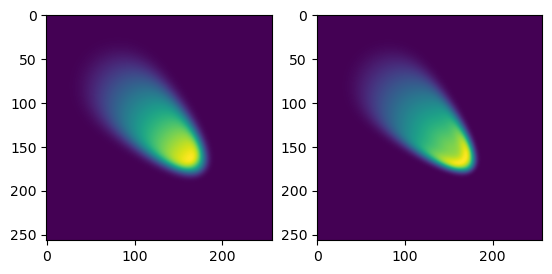

11 [0.856] 0.04400000000000004 0.013883948590440936 0.0129542041561274
0.01800625
[[ 2.24644819e-15  3.19989310e-15 -3.59086606e-15 ...  2.06913950e-63
   3.45752722e-64  6.49990899e-65]
 [ 1.02057913e-17  1.72330723e-17  3.52404504e-17 ...  3.04287510e-63
   5.06956537e-64  9.49410552e-65]
 [ 2.13887419e-17  3.52404504e-17  7.03503533e-17 ...  5.39412800e-63
   8.95306487e-64  1.66858245e-64]
 ...
 [ 2.06913950e-63  3.04287510e-63  5.39412800e-63 ...  1.55002236e-71
   8.82100790e-72  7.73549954e-72]
 [ 3.45752722e-64  5.06956537e-64  8.95306486e-64 ...  8.82100775e-72
  -1.37243112e-71 -2.64936735e-71]
 [ 6.49990898e-65  9.49410552e-65  1.66858245e-64 ...  7.73549957e-72
  -2.64936734e-71 -4.33765223e-71]]
0.00390625 RL sigma= 0.01800625 5 0.019351199075129576
0 0.016219588045380838
1 0.014634788522153993
2 0.01356896679848637
3 0.012780864793929505
4 0.012168428461995484


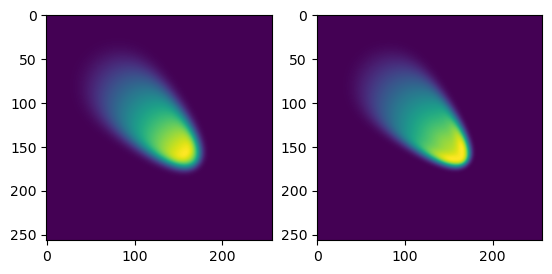

12 [0.776] 0.02400000000000002 0.01342600524889941 0.012168428461995484
0.017703906249999995
[[ 4.12710619e-15  6.94569732e-15 -1.12707854e-15 ...  2.33339206e-72
   4.36896952e-73  1.08334426e-73]
 [-2.86655701e-28 -2.33434073e-26 -8.92111315e-26 ...  2.95410711e-72
   6.03959339e-73  1.74077012e-73]
 [-3.01212510e-26 -8.92111299e-26 -2.23020853e-25 ...  4.82052590e-72
   1.06662883e-72  2.62869127e-73]
 ...
 [ 2.11172884e-72  3.08156721e-72  4.82052590e-72 ... -1.80737908e-81
  -9.35981191e-82  3.31691743e-82]
 [ 4.61072078e-73  5.85022712e-73  1.10430965e-72 ... -9.91054009e-82
   9.02328563e-82  1.13153657e-81]
 [ 1.08021987e-73  1.58024229e-73  2.89976205e-73 ...  3.55380324e-82
   1.11665330e-81  8.22157130e-82]]
0.00390625 RL sigma= 0.017703906249999995 5 0.029720910306261224
0 0.027460983107177376
1 0.02668557182862325
2 0.026308575876813546
3 0.02610863573025186
4 0.026000146965740392


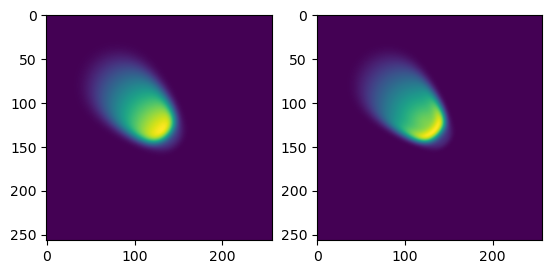

13 [0.418] 0.01799999999999996 0.023283629241287424 0.026000146965740392
0.018862890625000003
[[ 2.65154243e-15  2.02134777e-15 -4.21951962e-15 ...  4.03348007e-57
   8.56988688e-58  2.12412213e-58]
 [ 5.90503666e-16  8.46533275e-16  1.45290383e-15 ...  5.65712117e-57
   1.20074141e-57  2.97229965e-58]
 [ 1.02284842e-15  1.45290383e-15  2.46686035e-15 ...  9.48904033e-57
   2.01136396e-57  4.97039732e-58]
 ...
 [ 4.03348007e-57  5.65712117e-57  9.48904033e-57 ... -3.38080199e-66
  -1.60522577e-66  6.35480465e-67]
 [ 8.56988688e-58  1.20074141e-57  2.01136396e-57 ... -1.60522577e-66
   1.53036235e-66  2.05288485e-66]
 [ 2.12412213e-58  2.97229965e-58  4.97039732e-58 ...  6.35480464e-67
   2.05288485e-66  1.35449511e-66]]
0.00390625 RL sigma= 0.018862890625000003 5 0.01854996694775049
0 0.01579914847152
1 0.014529062184078165
2 0.013704146621525663
3 0.013104715107012319
4 0.012644808180918152


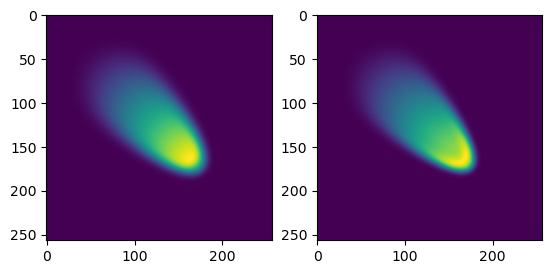

14 [0.859] 0.041000000000000036 0.01367780091050023 0.012644808180918152
0.017703906250000002
[[ 1.07747251e-15 -1.66963323e-15 -4.04141283e-15 ...  2.57432317e-72
   5.85388300e-73  1.49264182e-73]
 [-1.57572270e-27 -1.06317224e-25 -4.05218963e-25 ...  3.92434563e-72
   8.49838040e-73  2.17448124e-73]
 [-1.37233210e-25 -4.05218988e-25 -1.01172230e-24 ...  6.16996872e-72
   1.37539705e-72  3.53176404e-73]
 ...
 [ 2.82971120e-72  3.97008178e-72  6.16996872e-72 ... -2.43363727e-81
  -1.19669872e-81  4.29488576e-82]
 [ 5.69644378e-73  8.34094118e-73  1.33872801e-72 ... -1.06540349e-81
   1.08840453e-81  1.48341909e-81]
 [ 1.47539061e-73  1.97874217e-73  3.17478832e-73 ...  4.25837612e-82
   1.36315681e-81  9.36106758e-82]]
0.00390625 RL sigma= 0.017703906250000002 5 0.02761967583797922
0 0.023687186853714678
1 0.021577632716747498
2 0.020179516304680137
3 0.01918362937589631
4 0.01844338675122975


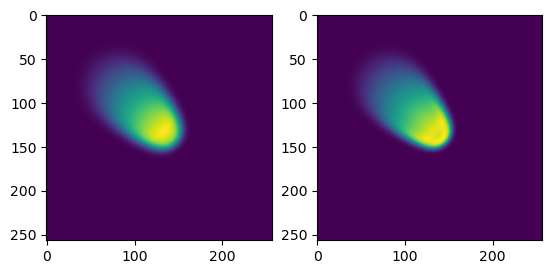

15 [0.482] 0.018000000000000016 0.020881430842249627 0.01844338675122975
0.0178046875
[[-4.45708704e-16  6.38924118e-15  4.17721520e-16 ...  9.19717406e-73
   1.85712169e-73  5.52714788e-74]
 [ 1.52287133e-29 -1.28498046e-30 -6.65046721e-29 ...  1.30882862e-72
   1.94555605e-73  6.74312041e-74]
 [ 8.87468518e-31 -6.65354870e-29 -2.39197418e-28 ...  1.91018231e-72
   5.04075886e-73  1.26018972e-73]
 ...
 [ 9.55091153e-73  1.27345487e-72  1.91018231e-72 ... -7.08303924e-82
  -3.37679778e-82  1.40013566e-82]
 [ 1.76868732e-73  2.91833408e-73  5.04075886e-73 ... -3.78860239e-82
   3.37679778e-82  4.85929436e-82]
 [ 5.30606196e-74  5.08497605e-74  1.37073267e-73 ...  1.31777474e-82
   4.69457252e-82  3.12971501e-82]]
0.00390625 RL sigma= 0.0178046875 5 0.03400629220780551
0 0.031668626644330546
1 0.030944074419100822
2 0.030647594416468044
3 0.030529520451804574
4 0.030495016298185126


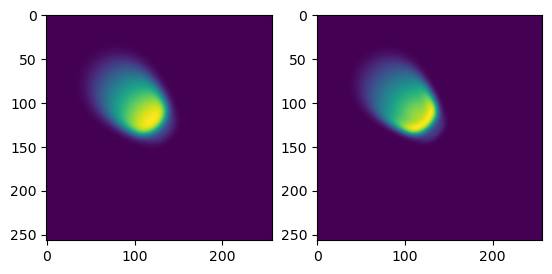

16 [0.32] 0.020000000000000018 0.027896641917498893 0.030495016298185126
0.0188125
[[ 2.26955348e-15  7.87900011e-15  5.51497519e-17 ...  1.52107110e-72
   3.00676844e-73  7.51692111e-74]
 [ 4.55505543e-29 -4.19082356e-30 -2.00235084e-28 ...  1.98092980e-72
   3.71424337e-73  1.10542958e-73]
 [ 2.39123462e-30 -2.00272062e-28 -7.18923456e-28 ...  2.97139470e-72
   7.07474928e-73  1.90133887e-73]
 ...
 [ 1.41494986e-72  2.05167729e-72  2.97139470e-72 ... -1.21894164e-81
  -6.09470819e-82  2.05902304e-82]
 [ 3.00676844e-73  4.06798084e-73  7.42848674e-73 ... -6.09470819e-82
   6.09470819e-82  7.57720477e-82]
 [ 6.85366337e-74  1.01699521e-73  1.81290450e-73 ...  2.22374488e-82
   6.91831740e-82  5.43582081e-82]]
0.00390625 RL sigma= 0.0188125 5 0.038731146323357835
0 0.03548356313204591
1 0.034107829971307055
2 0.03342839773181894
3 0.03310982269532233
4 0.03299465495696465


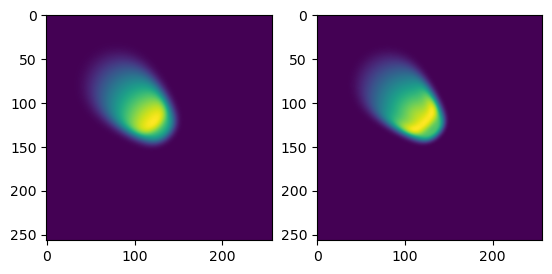

17 [0.36] 0.040000000000000036 0.03704850442890483 0.03299465495696465
0.017099218749999995
[[ 3.31329761e-15 -2.48232380e-15 -2.95984637e-15 ...  1.63353126e-64
   2.72962683e-65  5.13150715e-66]
 [ 7.92027616e-19  1.35587675e-18  2.81910060e-18 ...  2.40226994e-64
   4.00228857e-65  7.49534654e-66]
 [ 1.68318902e-18  2.81910060e-18  5.73969620e-18 ...  4.25852233e-64
   7.06820931e-65  1.31730194e-65]
 ...
 [ 1.63353126e-64  2.40226994e-64  4.25852233e-64 ...  1.22308435e-72
   6.95719045e-73  6.09924422e-73]
 [ 2.72962683e-65  4.00228857e-65  7.06820931e-65 ...  6.95719034e-73
  -1.08421416e-72 -2.09241571e-72]
 [ 5.13150715e-66  7.49534654e-66  1.31730195e-65 ...  6.09924425e-73
  -2.09241570e-72 -3.42537313e-72]]
0.00390625 RL sigma= 0.017099218749999995 5 0.018455057112871074
0 0.015750615723792903
1 0.014601166869016913
2 0.013896973341407916
3 0.013400227683932458
4 0.01302308894009329


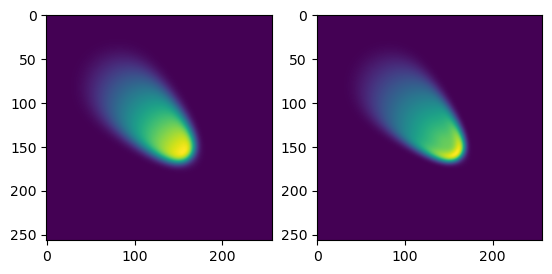

18 [0.706] 0.005999999999999894 0.010798470814142605 0.01302308894009329
0.01709921875
[[ 3.10883890e-15  1.66505576e-16 -4.46410671e-15 ...  6.42622086e-57
   1.36537154e-57  3.38419407e-58]
 [ 9.32833504e-16  1.33526176e-15  2.28729641e-15 ...  9.01303813e-57
   1.91304524e-57  4.73552752e-58]
 [ 1.61292676e-15  2.28729641e-15  3.87537767e-15 ...  1.51181278e-56
   3.20454527e-57  7.91893681e-58]
 ...
 [ 6.42622086e-57  9.01303813e-57  1.51181278e-56 ... -5.38637459e-66
  -2.55748523e-66  1.01245436e-66]
 [ 1.36537154e-57  1.91304524e-57  3.20454527e-57 ... -2.55748524e-66
   2.43821513e-66  3.27071857e-66]
 [ 3.38419407e-58  4.73552752e-58  7.91893681e-58 ...  1.01245436e-66
   3.27071857e-66  2.15804301e-66]]
0.00390625 RL sigma= 0.01709921875 5 0.015470304842350381
0 0.012534275950497437
1 0.011157108286263383
2 0.010263836176043012
3 0.009607414375730252
4 0.00909179472804954


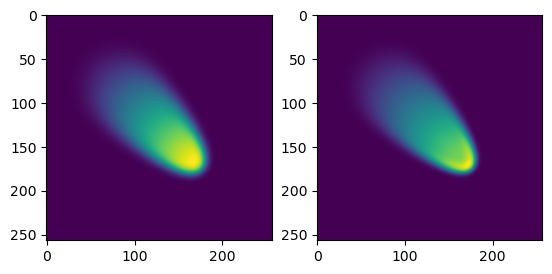

19 [0.894] 0.006000000000000005 0.008514543832527963 0.00909179472804954
0.3 0.02359938333792693


In [159]:
deconvolved = np.empty_like(X_test)
n_tests = len(mu_test)
e_old = np.zeros(n_tests,)
e_new = np.zeros(n_tests,)
fig, ax = plt.subplots()
sigma = 4.3 * dx
for i in range(n_tests):
    data = X_test_sROM[:, i].reshape(257, 257)
    d = neares_neighbour(mu_test[i], mu_train)
    dx2 = mu_train[1]-mu_train[0]
    c = .3
    sgm_est = sigma*(1+d/dx2*c)
    print(sgm_est)

    deconvolved[:, i] = richardson_lucy(x, data, sgm_est, num_iter=5, truth=X_test[:, i]).ravel()  # 82 0.0082487
    e_old[i] = np.mean((X_test[:, i]-smooth_ROM_sharpened[:, i])**2)**.5
    e_new[i] = np.mean((X_test[:, i]-deconvolved[:, i])**2)**.5
    
    print(i, mu_test[i], d, e_old[i], e_new[i])
ax.plot(e_old, "go")
ax.plot(e_new, "bx")
print(c, np.mean(e_new))
#     fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
#     ax1.imshow(X_test[:, i].reshape(257, 257), origin="lower", interpolation="nearest")
#     ax2.imshow(smooth_ROM_sharpened[:, i].reshape(257, 257), origin="lower", interpolation="nearest")
#     ax3.imshow(deconvolved[:, i].reshape(257, 257), origin="lower", interpolation="nearest")
#     plt.show()
plt.show()

In [ ]:
print(c, np.mean(e_old))